In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, make_scorer
import pickle


 

In [2]:
# Read data in the excel file
df = pd.read_excel('data.xlsx')
df.head()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,70,1,4,130,322.0,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564.0,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261.0,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263.0,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269.0,0,2,121,1,0.2,1,1,3,1


In [3]:
df.shape

(843, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 843 entries, 0 to 842
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AGE       843 non-null    int64  
 1   SEX       843 non-null    int64  
 2   CP        843 non-null    int64  
 3   TRESTBPS  843 non-null    int64  
 4   CHOL      843 non-null    float64
 5   FBS       843 non-null    int64  
 6   RESTECG   843 non-null    int64  
 7   THALACH   843 non-null    int64  
 8   EXANG     843 non-null    int64  
 9   OLDPEAK   843 non-null    float64
 10  SLOPE     843 non-null    int64  
 11  CA        843 non-null    object 
 12  THAL      843 non-null    object 
 13  TARGET    843 non-null    int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 92.3+ KB


In [5]:
df.describe()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,TARGET
count,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000
mean,54.260973,0.677343,3.166074,131.480427,248.275563,0.148280,1.010676,149.563464,0.327402,1.402135,1.588375,1.450771
std,9.430115,0.467770,0.955513,17.756616,52.320709,0.355588,0.995777,23.467554,0.469544,10.497029,0.616640,0.497866
min,5.000000,0.000000,0.000000,94.000000,2.300000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,1.000000
25%,47.000000,0.000000,3.000000,120.000000,212.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,244.000000,0.000000,2.000000,153.000000,0.000000,0.800000,2.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,277.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,304.000000,3.000000,2.000000


In [6]:
#Check null values
df.isnull().sum()
df=df[(df!='?').all(axis=1)]

In [7]:
df['TARGET'].value_counts()

1    459
2    378
Name: TARGET, dtype: int64

In [8]:
# Percentage of patients have and do not have heart disease
df['TARGET'].value_counts()/df.shape[0]*100

1    54.83871
2    45.16129
Name: TARGET, dtype: float64

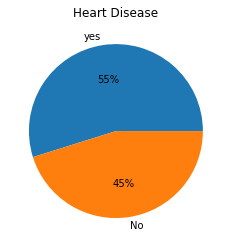

In [9]:
# Create a plot to display the percentage of the positive and negative heart disease 
labels = ['yes', 'No']
values = df['TARGET'].value_counts().values

plt.pie(values, labels=labels, autopct='%1.0f%%')
plt.title('Heart Disease')
plt.show()

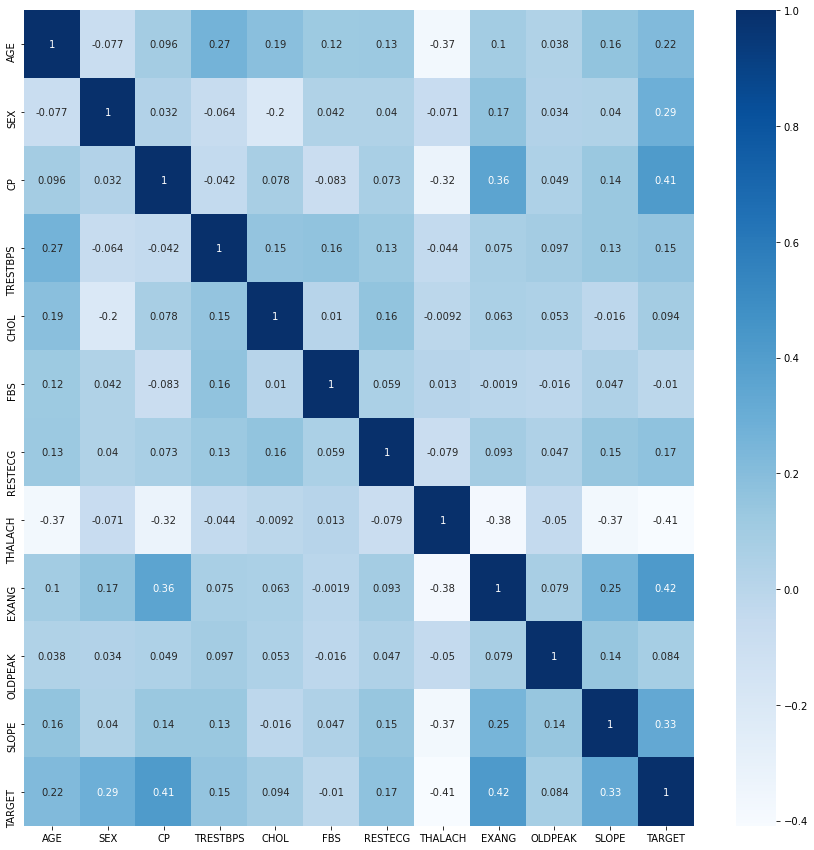

In [10]:
# Correlation map
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), annot = True, cmap = "Blues")
plt.show()

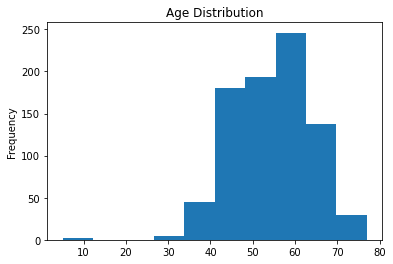

In [11]:
# Display age distribution
df['AGE'].plot(kind = 'hist', title = 'Age Distribution')
plt.show()

In [12]:
# Get min, max and average of the age
print('Min age: ', min(df['AGE']))
print('Max age: ', max(df['AGE']))
print('Average age: ', df['AGE'].mean())

Min age:  5
Max age:  77
Average age:  54.2962962962963


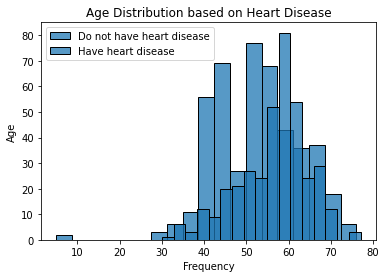

In [13]:
# Display age distribution based on heart disease
sns.histplot(df[df['TARGET'] == 1]['AGE'], label='Do not have heart disease')
sns.histplot(df[df['TARGET'] == 2]['AGE'], label = 'Have heart disease')
plt.xlabel('Frequency')
plt.ylabel('Age')
plt.title('Age Distribution based on Heart Disease')
plt.legend()
plt.show()

In [14]:
# Get min, max and average of the age of the people do not have heart diseas
print('Min age of people who do not have heart disease: ', min(df[df['TARGET'] == 1]['AGE']))
print('Max age of people who do not have heart disease: ', max(df[df['TARGET'] == 1]['AGE']))
print('Average age of people who do not have heart disease: ', df[df['TARGET'] == 1]['AGE'].mean())

Min age of people who do not have heart disease:  5
Max age of people who do not have heart disease:  76
Average age of people who do not have heart disease:  52.42047930283224


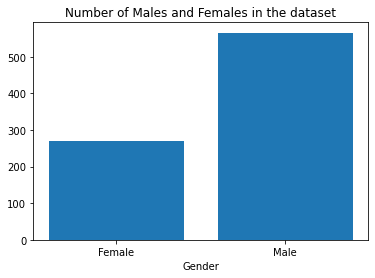

In [15]:
# Number of males and females
F = df[df['SEX'] == 0].count()['TARGET']
M = df[df['SEX'] == 1].count()['TARGET']

# Create a plot
figure, ax = plt.subplots(figsize = (6, 4))
ax.bar(x = ['Female', 'Male'], height = [F, M])
plt.xlabel('Gender')
plt.title('Number of Males and Females in the dataset')
plt.show()

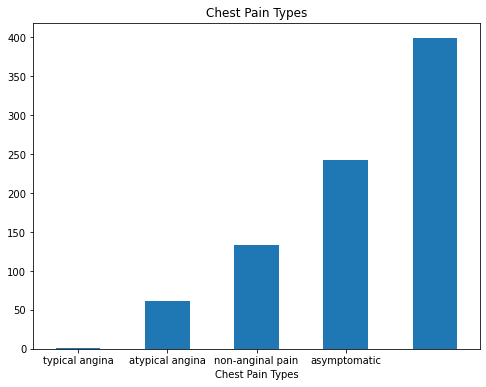

In [16]:
# Display chest pain types in bar chart
df.groupby(df['CP']).count()['TARGET'].plot(kind = 'bar', title = 'Chest Pain Types', figsize = (8, 6))
plt.xlabel('Chest Pain Types')
plt.xticks(np.arange(4), ('typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'), rotation = 0)
plt.show()

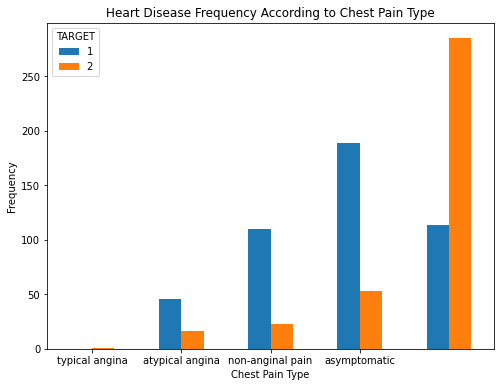

In [17]:
# Display chest pain types based on the target
pd.crosstab(df.CP,df.TARGET).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease Frequency According to Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.xticks(np.arange(4), ('typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'), rotation = 0)
plt.ylabel('Frequency')
plt.show()

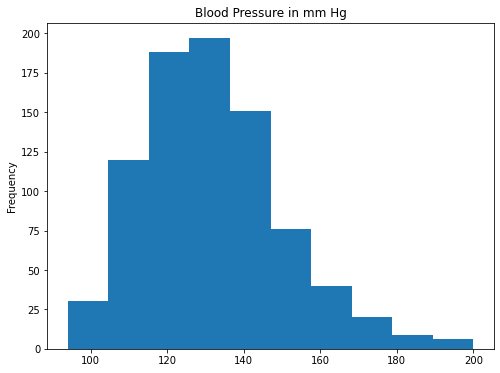

In [18]:
# Display blood pressure distribution
df['TRESTBPS'].plot(kind = 'hist', title = 'Blood Pressure in mm Hg', figsize = (8, 6))
plt.show()

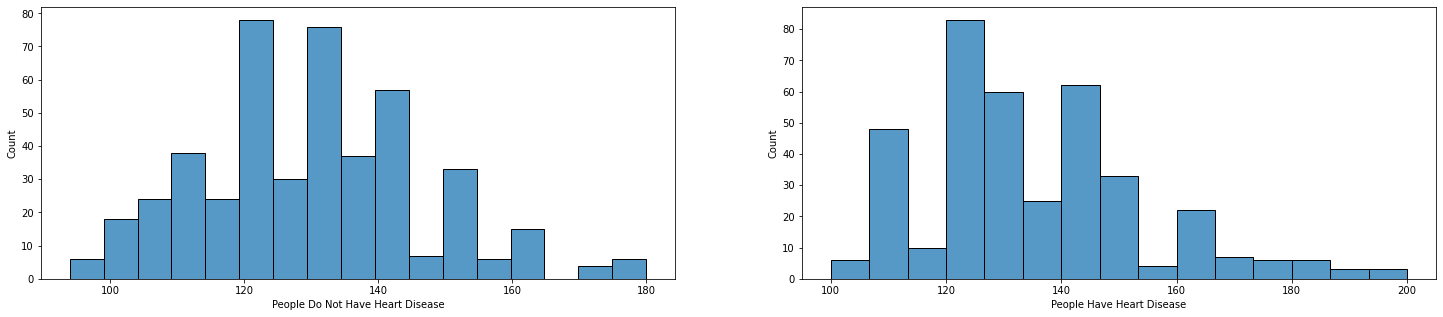

In [19]:
# Display blood pressure distribution based on heart disease
fig, (axis1, axis2) = plt.subplots(1, 2,figsize=(25, 5))
ax = sns.histplot(df[df['TARGET'] == 1]['TRESTBPS'], label='Do not have heart disease', ax = axis1)
ax.set(xlabel='People Do Not Have Heart Disease')
ax = sns.histplot(df[df['TARGET'] == 2]['TRESTBPS'], label = 'Have heart disease', ax = axis2)
ax.set(xlabel='People Have Heart Disease')
plt.show()

In [20]:
# Get min, max and average of the  blood pressure of the people do not have heart diseas
print('Min blood pressure of people who do not have heart disease: ', min(df[df['TARGET'] == 1]['TRESTBPS']))
print('Max blood pressure of people who do not have heart disease: ', max(df[df['TARGET'] == 1]['TRESTBPS']))
print('Average blood pressure of people who do not have heart disease: ', df[df['TARGET'] == 1]['TRESTBPS'].mean())

Min blood pressure of people who do not have heart disease:  94
Max blood pressure of people who do not have heart disease:  180
Average blood pressure of people who do not have heart disease:  129.0152505446623


In [21]:
# Get min, max and average of the blood pressure of the people have heart diseas
print('Min blood pressure of people who have heart disease: ', min(df[df['TARGET'] == 2]['TRESTBPS']))
print('Max blood pressure of people who have heart disease: ', max(df[df['TARGET'] == 2]['TRESTBPS']))
print('Average blood pressure of people who have heart disease: ', df[df['TARGET'] == 2]['TRESTBPS'].mean())

Min blood pressure of people who have heart disease:  100
Max blood pressure of people who have heart disease:  200
Average blood pressure of people who have heart disease:  134.47354497354496


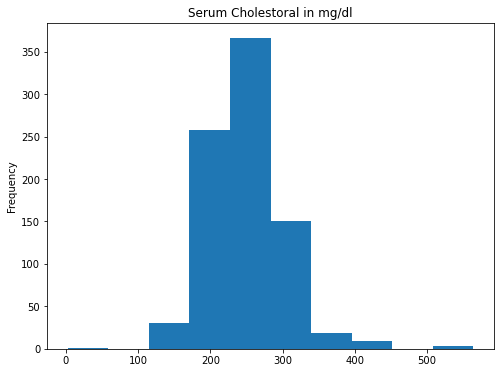

In [22]:
# Display Cholestoral distribution
df['CHOL'].plot(kind = 'hist', title = 'Serum Cholestoral in mg/dl', figsize = (8, 6))
plt.show()

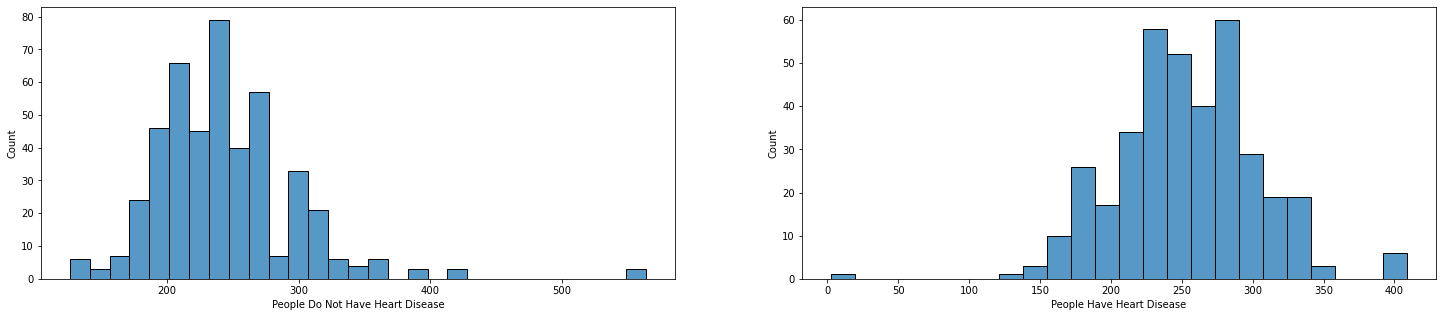

In [23]:
# Display Cholestoral distribution based on heart disease
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(25, 5))
ax = sns.histplot(df[df['TARGET'] == 1]['CHOL'], label='Do not have heart disease', ax = axis1)
ax.set(xlabel='People Do Not Have Heart Disease')
ax = sns.histplot(df[df['TARGET'] == 2]['CHOL'], label = 'Have heart disease', ax = axis2)
ax.set(xlabel='People Have Heart Disease')
plt.show()

In [24]:
# Get min, max and average of the Cholestoral of the people do not have heart diseas
print('Min cholestoral of people who do not have heart disease: ', min(df[df['TARGET'] == 1]['CHOL']))
print('Max cholestoral of people who do not have heart disease: ', max(df[df['TARGET'] == 1]['CHOL']))
print('Average cholestoral of people who do not have heart disease: ', df[df['TARGET'] == 1]['CHOL'].mean())

Min cholestoral of people who do not have heart disease:  126.0
Max cholestoral of people who do not have heart disease:  564.0
Average cholestoral of people who do not have heart disease:  244.0566448801743


In [25]:
# Get min, max and average of the Cholestoral of the people have heart diseas
print('Min cholestoral of people who have heart disease: ', min(df[df['TARGET'] == 2]['CHOL']))
print('Max cholestoral of people who have heart disease: ', max(df[df['TARGET'] == 2]['CHOL']))
print('Average cholestorale of people who have heart disease: ', df[df['TARGET'] == 2]['CHOL'].mean())

Min cholestoral of people who have heart disease:  2.3
Max cholestoral of people who have heart disease:  409.0
Average cholestorale of people who have heart disease:  253.9399470899471


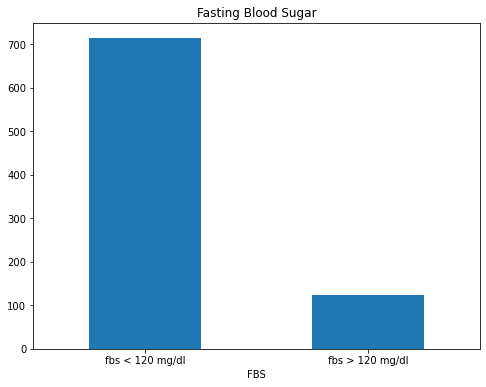

In [26]:
# Display fasting blood sugar in bar chart
df.groupby(df['FBS']).count()['TARGET'].plot(kind = 'bar', title = 'Fasting Blood Sugar', figsize = (8, 6))
plt.xticks(np.arange(2), ('fbs < 120 mg/dl', 'fbs > 120 mg/dl'), rotation = 0)
plt.show()

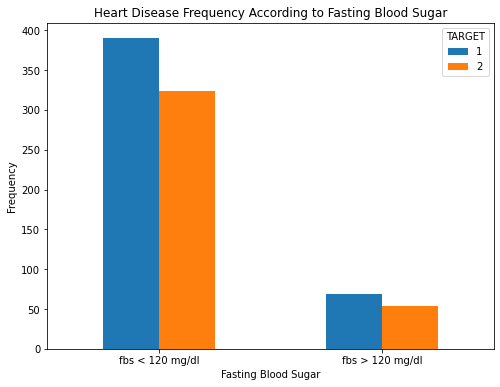

In [27]:
# Display fasting blood sugar based on the target
pd.crosstab(df.FBS,df.TARGET).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease Frequency According to Fasting Blood Sugar')
plt.xlabel('Fasting Blood Sugar')
plt.xticks(np.arange(2), ('fbs < 120 mg/dl', 'fbs > 120 mg/dl'), rotation = 0)
plt.ylabel('Frequency')
plt.show()

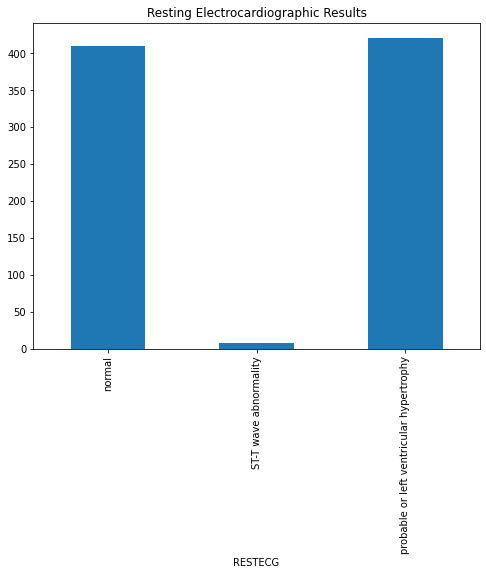

In [28]:
# Display electrocardiographic results in bar chart
df.groupby(df['RESTECG']).count()['TARGET'].plot(kind = 'bar', title = 'Resting Electrocardiographic Results', figsize = (8, 6))
plt.xticks(np.arange(3), ('normal', 'ST-T wave abnormality', 'probable or left ventricular hypertrophy'))
plt.show()

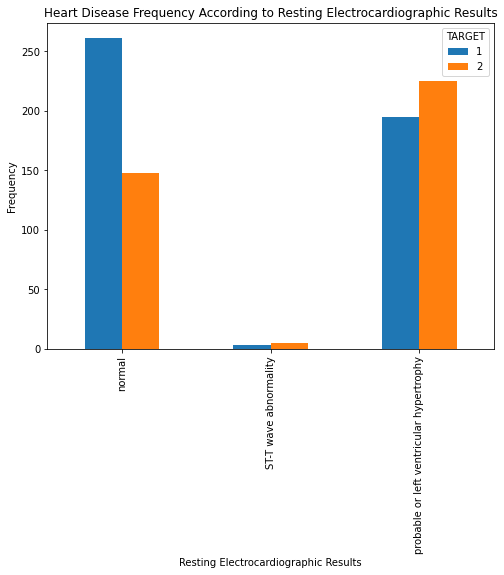

In [29]:
# Display resting electrocardiographic results based on the target
pd.crosstab(df.RESTECG,df.TARGET).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease Frequency According to Resting Electrocardiographic Results')
plt.xticks(np.arange(3), ('normal', 'ST-T wave abnormality', 'probable or left ventricular hypertrophy'))
plt.xlabel('Resting Electrocardiographic Results')
plt.ylabel('Frequency')
plt.show()


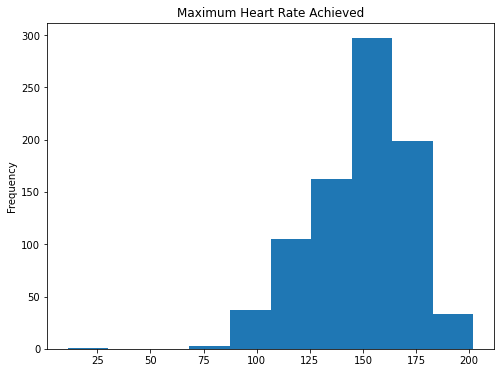

In [30]:
# Display maximum heart rate distribution
df['THALACH'].plot(kind = 'hist', title = 'Maximum Heart Rate Achieved', figsize = (8, 6))
plt.show()

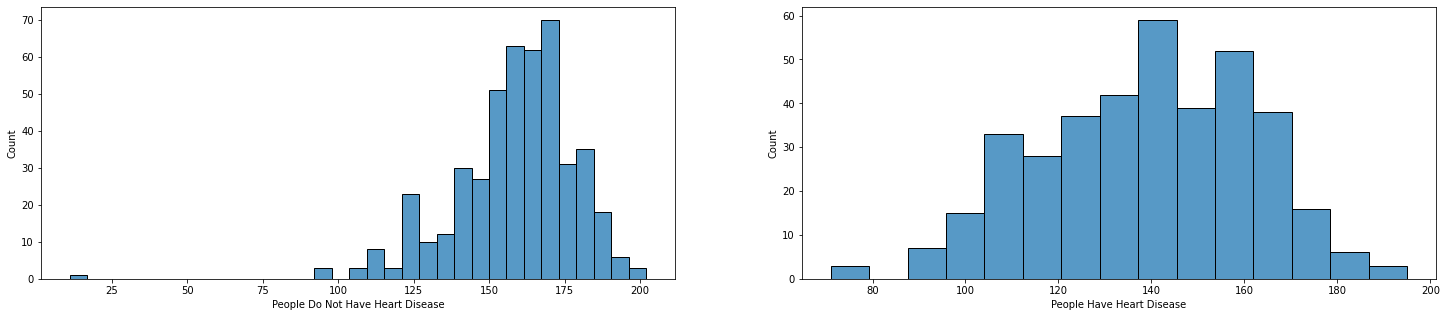

In [31]:
# Display maximum heart rate distribution based on heart disease
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(25, 5))
ax = sns.histplot(df[df['TARGET'] == 1]['THALACH'], label='Do not have heart disease', ax = axis1)
ax.set(xlabel = 'People Do Not Have Heart Disease')
ax = sns.histplot(df[df['TARGET'] == 2]['THALACH'], label = 'Have heart disease', ax = axis2)
ax.set(xlabel = 'People Have Heart Disease')
plt.show()

In [32]:
# Get min, max and average of the maximum heart rate of the people do not have heart diseas
print('Min resting blood pressure of people who do not have heart disease: ', min(df[df['TARGET'] == 1]['THALACH']))
print('Max resting blood pressure of people who do not have heart disease: ', max(df[df['TARGET'] == 1]['THALACH']))
print('Average resting blood pressure of people who do not have heart disease: ', df[df['TARGET'] == 1]['THALACH'].mean())

Min resting blood pressure of people who do not have heart disease:  11
Max resting blood pressure of people who do not have heart disease:  202
Average resting blood pressure of people who do not have heart disease:  158.27233115468408


In [33]:
# Get min, max and average of the maximum heart rate of the people have heart diseas
print('Min maximum heart rate  of people who have heart disease: ', min(df[df['TARGET'] == 2]['THALACH']))
print('Max maximum heart rate people who have heart disease: ', max(df[df['TARGET'] == 2]['THALACH']))
print('Average maximum heart rate of people who have heart disease: ', df[df['TARGET'] == 2]['THALACH'].mean())

Min maximum heart rate  of people who have heart disease:  71
Max maximum heart rate people who have heart disease:  195
Average maximum heart rate of people who have heart disease:  138.9814814814815


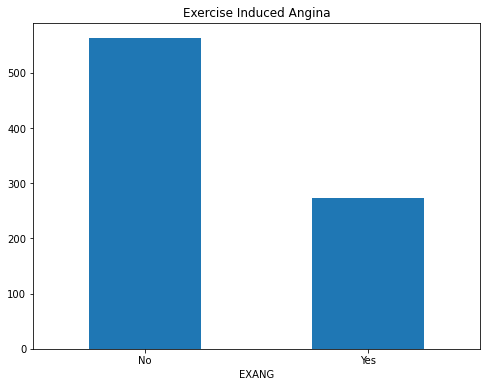

In [34]:
# Display exercise induced angina in bar chart
df.groupby(df['EXANG']).count()['TARGET'].plot(kind = 'bar', title = 'Exercise Induced Angina',  figsize = (8, 6))
plt.xticks(np.arange(2), ('No', 'Yes'), rotation = 0)
plt.show()

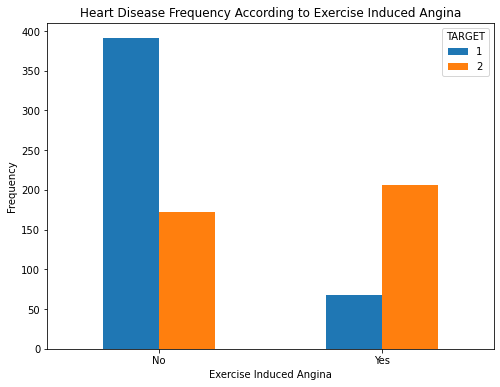

In [35]:
# Display exercise induced angina based on the target
pd.crosstab(df.EXANG,df.TARGET).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease Frequency According to Exercise Induced Angina')
plt.xlabel('Exercise Induced Angina')
plt.xticks(np.arange(2), ('No', 'Yes'), rotation = 0)
plt.ylabel('Frequency')
plt.show()

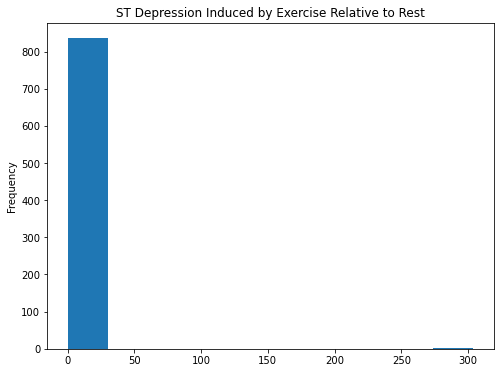

In [36]:
# Display ST depression induced by exercise relative to rest distribution
df['OLDPEAK'].plot(kind = 'hist', title = 'ST Depression Induced by Exercise Relative to Rest', figsize = (8, 6))
plt.show()

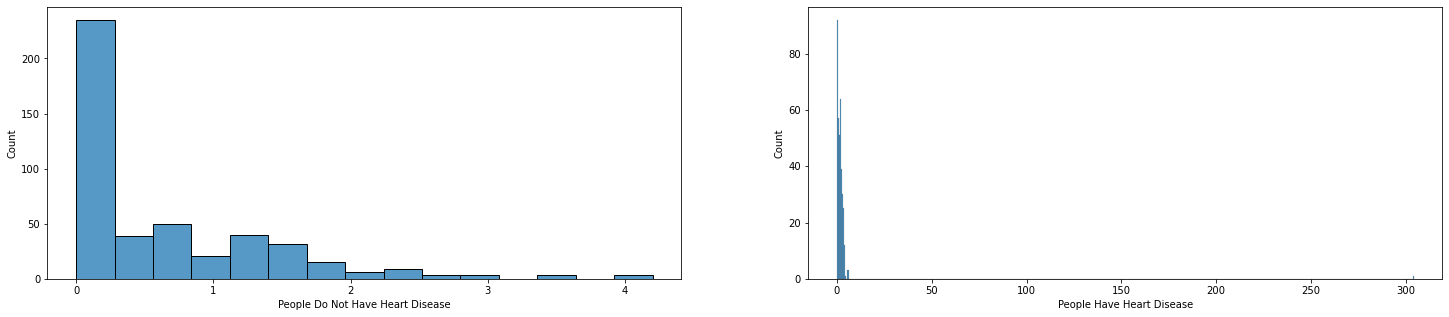

In [37]:
# Display ST depression distribution based on heart disease
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(25, 5))
ax = sns.histplot(df[df['TARGET'] == 1]['OLDPEAK'], label='Do not have heart disease', ax = axis1)
ax.set(xlabel = 'People Do Not Have Heart Disease')
ax = sns.histplot(df[df['TARGET'] == 2]['OLDPEAK'], label = 'Have heart disease', ax = axis2)
ax.set(xlabel = 'People Have Heart Disease')
plt.show()


In [38]:
# Get min, max and average of the ST depression  of the people have heart diseas
print('Min ST depression of people who do not have heart disease: ', min(df[df['TARGET'] == 1]['OLDPEAK']))
print('Max ST depression of people who do not have heart disease: ', max(df[df['TARGET'] == 1]['OLDPEAK']))
print('Average ST depression of people who do not have heart disease: ', df[df['TARGET'] == 1]['OLDPEAK'].mean())

Min ST depression of people who do not have heart disease:  0.0
Max ST depression of people who do not have heart disease:  4.2
Average ST depression of people who do not have heart disease:  0.6124183006535944


In [39]:
# Get min, max and average of the ST depression of the people have heart diseas
print('Min ST depression of people who have heart disease: ', min(df[df['TARGET'] == 2]['OLDPEAK']))
print('Max ST depression of people who have heart disease: ', max(df[df['TARGET'] == 2]['OLDPEAK']))
print('Average ST depression of people not have heart disease: ', df[df['TARGET'] == 2]['OLDPEAK'].mean())

Min ST depression of people who have heart disease:  0.0
Max ST depression of people who have heart disease:  304.0
Average ST depression of people not have heart disease:  2.37936507936508


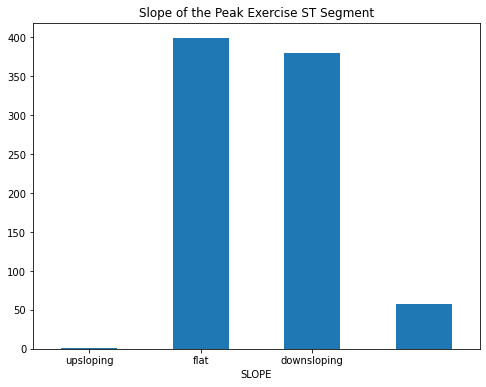

In [40]:
# Display slope of the peak exercise ST segment in bar chart
df.groupby(df['SLOPE']).count()['TARGET'].plot(kind = 'bar', title = 'Slope of the Peak Exercise ST Segment', figsize = (8, 6))
plt.xticks(np.arange(3), ('upsloping', 'flat', 'downsloping'), rotation = 0)
plt.show()

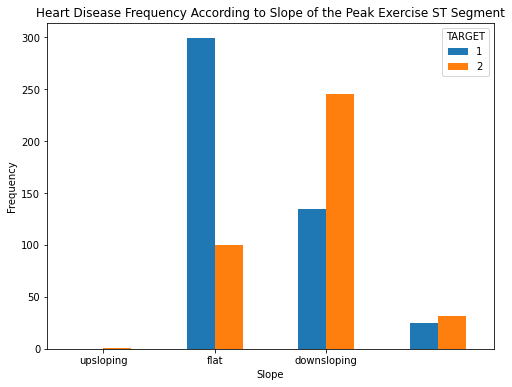

In [41]:
# Display slope of the peak exercise ST segment based on the target
pd.crosstab(df.SLOPE,df.TARGET).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease Frequency According to Slope of the Peak Exercise ST Segment')
plt.xlabel('Slope')
plt.xticks(np.arange(3), ('upsloping', 'flat', 'downsloping'), rotation = 0)
plt.ylabel('Frequency')
plt.show()

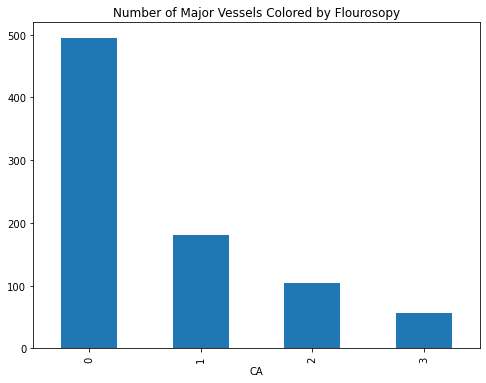

In [42]:
# Display number of major vessels in bar chart
df.groupby(df['CA']).count()['TARGET'].plot(kind = 'bar', title = 'Number of Major Vessels Colored by Flourosopy', 
                                            figsize = (8, 6))
plt.show()

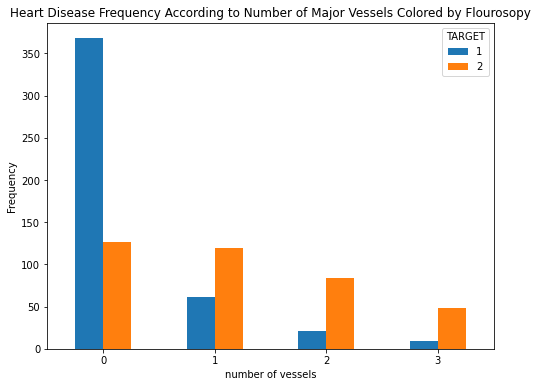

In [43]:
# Display number of vessels based on the target
pd.crosstab(df.CA,df.TARGET).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease Frequency According to Number of Major Vessels Colored by Flourosopy')
plt.xlabel('number of vessels')
plt.xticks(rotation = 0)
plt.ylabel('Frequency')
plt.show()

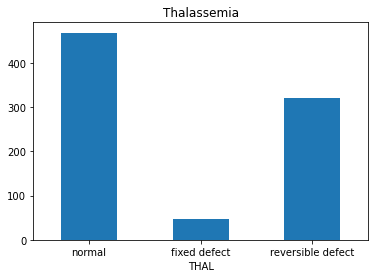

In [44]:
# Display thalassemia in bar chart
df.groupby(df['THAL']).count()['TARGET'].plot(kind = 'bar', title = 'Thalassemia')
plt.xticks(np.arange(3), ('normal', 'fixed defect', 'reversible defect'), rotation = 0)
plt.show()

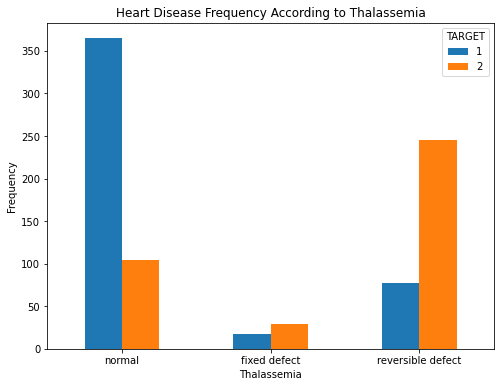

In [45]:
pd.crosstab(df.THAL,df.TARGET).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease Frequency According to Thalassemia')
plt.xlabel('Thalassemia')
plt.xticks(np.arange(3), ('normal', 'fixed defect', 'reversible defect'), rotation = 0)
plt.ylabel('Frequency')
plt.show()

C:\Anaconda\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


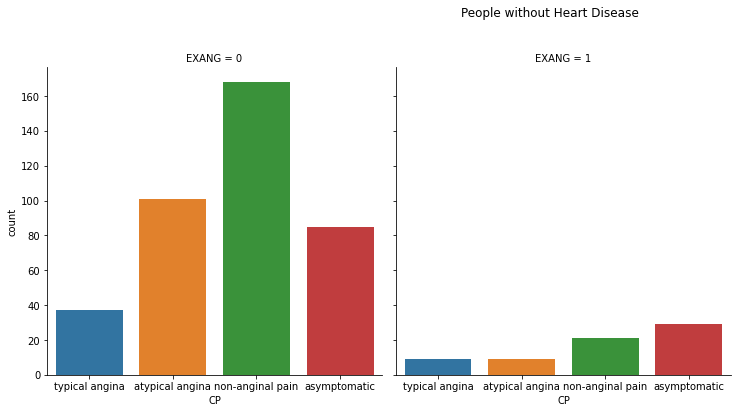

In [46]:
g = sns.catplot("CP", col = "EXANG", col_wrap = 3, data = df[df['TARGET'] == 1], kind = "count")
plt.xticks(np.arange(4), ('typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'), rotation = 0)
g.fig.suptitle('People without Heart Disease', y = 1.1)
plt.show()

C:\Anaconda\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


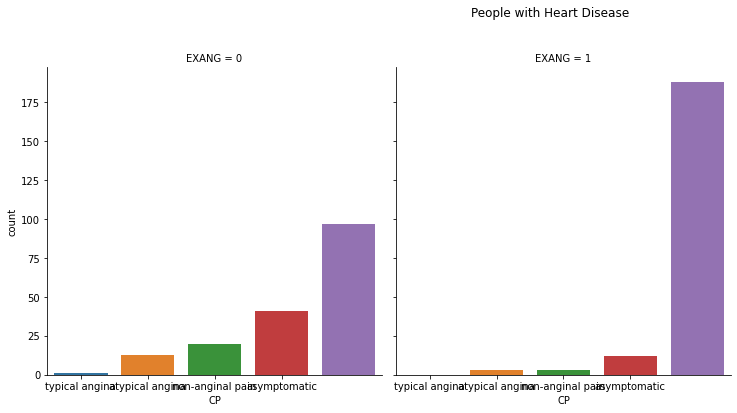

In [47]:
g = sns.catplot("CP", col = "EXANG", col_wrap = 3, data = df[df['TARGET'] == 2], kind = "count")
plt.xticks(np.arange(4), ('typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'), rotation = 0)
g.fig.suptitle('People with Heart Disease', y = 1.1)
plt.show()

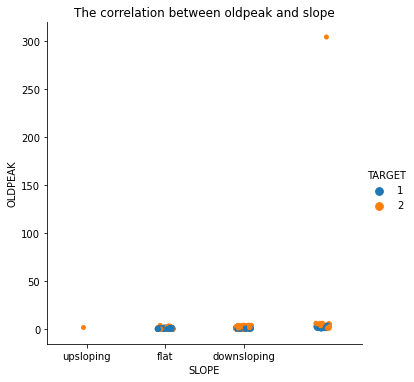

In [48]:
sns.catplot(x = "SLOPE", y = "OLDPEAK", hue = "TARGET", data = df)
plt.title('The correlation between oldpeak and slope')
plt.xticks(np.arange(3), ('upsloping', 'flat', 'downsloping'), rotation = 0)
plt.show()

C:\Anaconda\anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 47.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Anaconda\anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 28.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Anaconda\anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 12.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


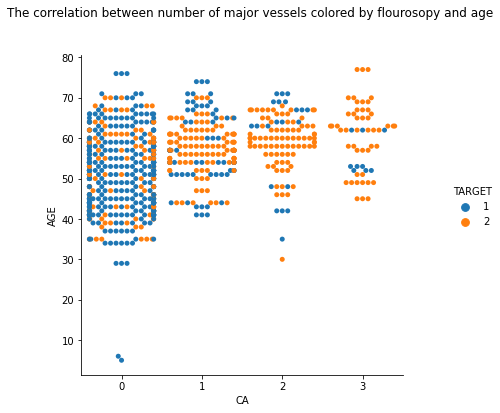

In [49]:
g = sns.catplot(x = 'CA', y = 'AGE', hue = 'TARGET', data = df, kind="swarm")
g.fig.suptitle('The correlation between number of major vessels colored by flourosopy and age', y = 1.1)
plt.show()

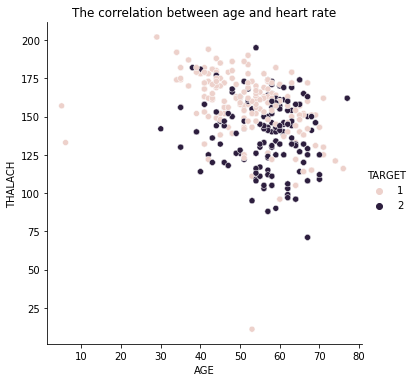

In [50]:
sns.relplot(x = 'AGE', y = 'THALACH', data = df, hue = 'TARGET', legend="full")
plt.title('The correlation between age and heart rate')
plt.show()

In [51]:
# Initialize data and target
target = df['TARGET']
features = df.drop(['TARGET'], axis = 1)

In [52]:
# Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 0)

In [53]:
# Train and evaluate model
def fit_eval_model(model, train_features, y_train, test_features, y_test):
    
    """
    Function: train and evaluate a machine learning classifier.
    Args:
      model: machine learning classifier
      train_features: train data extracted features
      y_train: train data lables
      test_features: train data extracted features
      y_test: train data lables
    Return:
      results(dictionary): a dictionary of classification report
    """
    results = {}
    
    # Train the model
    model.fit(train_features, y_train)
    
    # Test the model
    train_predicted = model.predict(train_features)
    test_predicted = model.predict(test_features)
    
     # Classification report and Confusion Matrix
    results['classification_report'] = classification_report(y_test, test_predicted)
    results['confusion_matrix'] = confusion_matrix(y_test, test_predicted)
        
    return results

In [54]:
sv = SVC(random_state = 1)
rf = RandomForestClassifier(random_state = 1)
ab = AdaBoostClassifier(random_state = 1)
gb = GradientBoostingClassifier(random_state = 1)


# Fit and evaluate models
results = {}
for cls in [sv, rf, ab, gb]:
    cls_name = cls.__class__.__name__
    results[cls_name] = {}
    results[cls_name] = fit_eval_model(cls, X_train, y_train, X_test, y_test)

In [55]:
# Print classifiers results
for result in results:
    print (result)
    print()
    for i in results[result]:
        print (i, ':')
        print(results[result][i])
        print()
    print ('-----')
    print()

SVC

classification_report :
              precision    recall  f1-score   support

           1       0.74      0.86      0.80       100
           2       0.73      0.56      0.63        68

    accuracy                           0.74       168
   macro avg       0.74      0.71      0.71       168
weighted avg       0.74      0.74      0.73       168


confusion_matrix :
[[86 14]
 [30 38]]

-----

RandomForestClassifier

classification_report :
              precision    recall  f1-score   support

           1       0.97      1.00      0.99       100
           2       1.00      0.96      0.98        68

    accuracy                           0.98       168
   macro avg       0.99      0.98      0.98       168
weighted avg       0.98      0.98      0.98       168


confusion_matrix :
[[100   0]
 [  3  65]]

-----

AdaBoostClassifier

classification_report :
              precision    recall  f1-score   support

           1       0.93      0.92      0.92       100
           2      

Feature: AGE, Score: 0.09169
Feature: SEX, Score: 0.02534
Feature: CP, Score: 0.11797
Feature: TRESTBPS, Score: 0.07886
Feature: CHOL, Score: 0.08217
Feature: FBS, Score: 0.00961
Feature: RESTECG, Score: 0.02156
Feature: THALACH, Score: 0.11673
Feature: EXANG, Score: 0.03728
Feature: OLDPEAK, Score: 0.10558
Feature: SLOPE, Score: 0.04919
Feature: CA, Score: 0.12647
Feature: THAL, Score: 0.13756


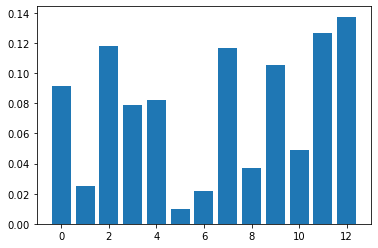

In [58]:
# get importance
importance = rf.feature_importances_
# summarize feature importance
for i,v in enumerate(importance):
    print('Feature: %s, Score: %.5f' % (features.columns[i], v))
# plot feature importance
plt.bar([x for x in range(len(importance))], importance)
plt.show()

In [59]:
# Save the model as serialized object pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(rf, file)
